# Regresion

## Bibliotecas

In [1]:
#pip install pyfixest

In [2]:
# Importar bibliotecas
import os
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns

warnings.filterwarnings("ignore")

In [3]:
# folders
path = "C:/Users/et396/OneDrive/Dropbox/"
base = "Docencia/UNAC/Evaluation/S1/Code/"

# Direccion de folder
data_in = path+base

## Importar data

In [4]:
# Information de base
data = pd.read_csv(data_in + "BD1.csv")

In [5]:
print('==================== ============================')
print('Informacion filas y columnas', data.shape)
print('Informacion de observacion (aleatorias') 
print('==================== ============================')
data.head().sample(5)

==================== ============================
Informacion filas y columnas (174467, 11)
Informacion de observacion (aleatorias
==================== ============================


,rcod_hogar,rcod_person,r6,rmujer,redad,rinformal,rDpto,rocu,reduca,ryear,rneduca
2,500702211,50070221101,2224.665202,0,62,0,Amazonas,1,5,2021,16.0
4,500702211,50070221103,0.000000,0,29,0,Amazonas,2,4,2021,14.0
1,500701211,50070121101,1062.165853,1,21,1,Amazonas,1,3,2021,11.0
3,500702211,50070221102,1619.210449,1,61,0,Amazonas,1,4,2021,14.0
0,500700311,50070031101,6433.593913,0,56,0,Amazonas,1,5,2021,17.0


## Variables

In [6]:
# Creamos la variable de logaritmo de ingresos
data['logr6'] = np.where(data['r6']>0, np.log(data['r6']),np.nan)

base = data.loc[data['logr6']>0] 
base = data.loc[data['redad']<70] 

# Creamos la variable edad al cuadrado
base['redadsq'] = base['redad']* base['redad']

print("Filas y columnas       :",base.shape)
base.sample(5)

Filas y columnas       : (156887, 13)


,rcod_hogar,rcod_person,r6,rmujer,redad,rinformal,rDpto,rocu,reduca,ryear,rneduca,logr6,redadsq
49347,1727412611,172741261101,382.000000,0,33,1,Junin,1,3,2021,11.0,5.945421,1089
42602,1670111611,167011161101,619.916667,0,61,1,Huanuco,1,3,2021,7.0,6.429585,3721
43751,1680031811,168003181102,0.000000,1,66,1,Huanuco,1,1,2021,NaN,NaN,4356
59890,1817314711,181731471103,0.000000,0,40,0,Lima,3,3,2021,11.0,NaN,1600
63434,1845202723,184520272305,1225.217204,0,21,1,Lima,1,3,2021,11.0,7.110873,441


In [7]:
variables = ['r6','rneduca','redad','rinformal','rmujer']
base[variables].describe()

,r6,rneduca,redad,rinformal,rmujer
count,156887.000000,151661.000000,156887.000000,156887.000000,156887.000000
mean,875.459738,9.373188,38.256331,0.567702,0.520451
std,1520.741462,5.062132,15.983146,0.495397,0.499583
min,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,7.000000,24.000000,0.000000,0.000000
50%,379.333333,11.000000,38.000000,1.000000,1.000000
75%,1232.401774,13.000000,51.000000,1.000000,1.000000
max,103618.000000,18.000000,69.000000,1.000000,1.000000


## Analisis descriptivo

Text(0, 0.5, 'Salarios (Soles)')

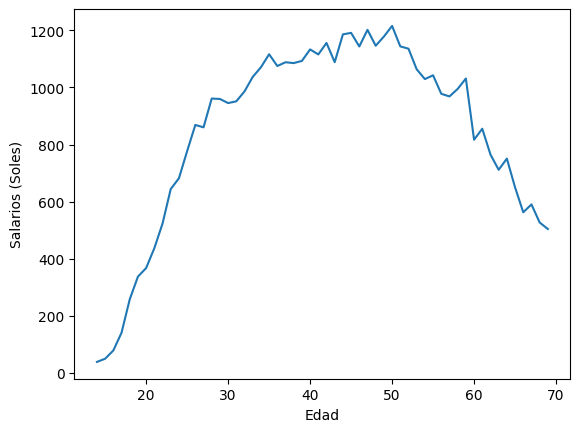

In [8]:
graph1 = base.loc[base['ryear']==2021].groupby(['redad'])['r6'].mean().reset_index()
fig = sns.lineplot(
    data=graph1,
    x='redad',
    y='r6'
)
plt.xlabel("Edad")
plt.ylabel("Salarios (Soles)")

Text(0, 0.5, 'Salarios (Soles)')

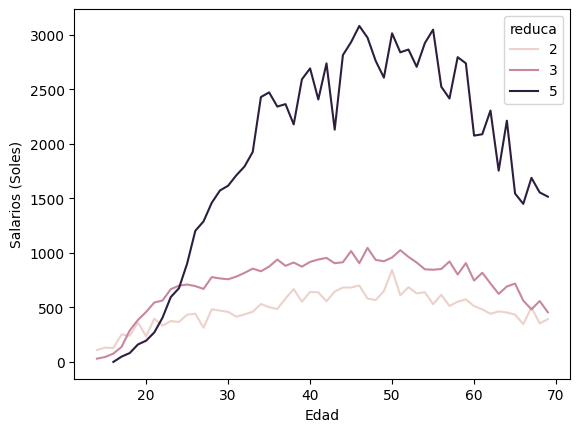

In [9]:
graph2 = base.loc[base['ryear']==2021].groupby(['redad','reduca'])['r6'].mean().reset_index()
fig = sns.lineplot(
    data=graph2.loc[(graph2['reduca']==2) |  (graph2['reduca']==3) |  (graph2['reduca']==5) ],
    x='redad',
    y='r6',
    hue='reduca'
)
plt.xlabel("Edad")
plt.ylabel("Salarios (Soles)")

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


reduca
3    72554
2    33903
5    24787
4    20233
1     5128
6      282
Name: count, dtype: int64


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


[Text(0, 0, '268.951'),
 Text(0, 0, '566.485'),
 Text(0, 0, '659.787'),
 Text(0, 0, '1241.25'),
 Text(0, 0, '1764.68'),
 Text(0, 0, '135.616')]

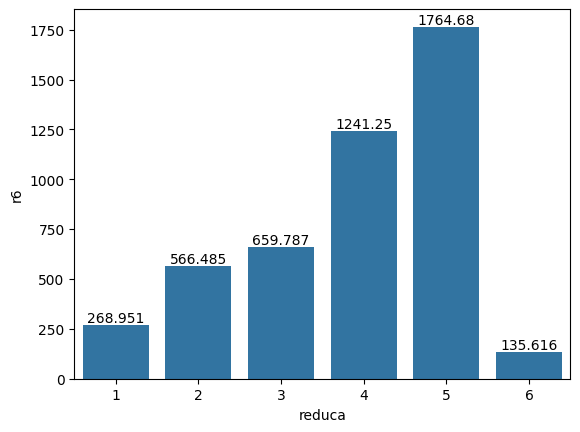

In [12]:
# Grafico de barras  de ingresos mensuales
print(base['reduca'].value_counts())
ax = sns.barplot(
    data = base,
    x='reduca',
    y='r6',
    errorbar=None
)
ax.bar_label(ax.containers[0], fontsize=10)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='reduca', ylabel='r6'>

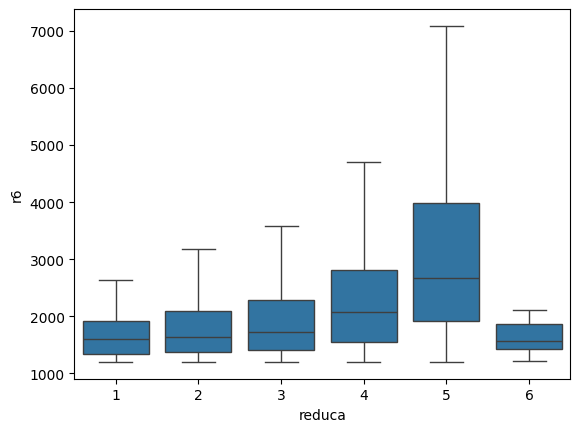

In [41]:
sns.boxplot(
    data=base.loc[base['r6']>=1200],
    y='r6',
    x='reduca',
    showfliers=False
)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: xlabel='reduca', ylabel='r6'>

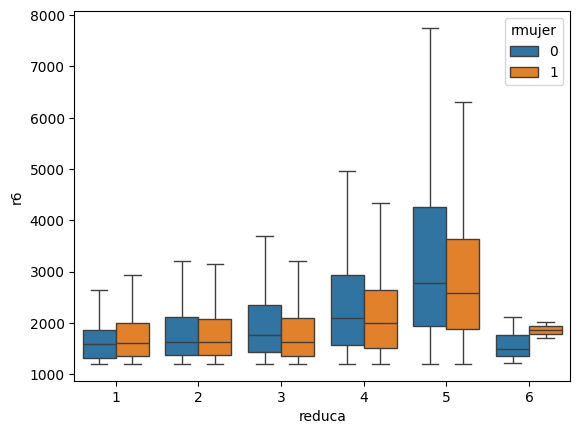

In [42]:
sns.boxplot(
    data=base.loc[base['r6']>=1200],
    y='r6',
    x='reduca',
    hue='rmujer',
    showfliers=False
)

<Axes: xlabel='logr6', ylabel='Density'>

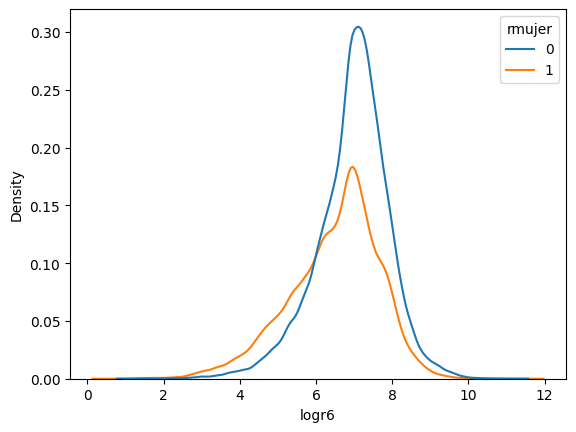

In [11]:
sns.kdeplot(
    data=base,
    x='logr6',
    hue='rmujer',
)

# Pregunta 1

In [13]:
formula = "logr6 ~ rneduca"
import pyfixest as pf
m1 = pf.feols(formula,data=base)

pf.etable(m1)

GT(_tbl_data=  level_0             level_1                      0
0    coef             rneduca  0.069*** <br> (0.001)
1    coef           Intercept  6.117*** <br> (0.007)
2   stats        Observations                  95224
3   stats           S.E. type                    iid
4   stats       R<sup>2</sup>                  0.115
5   stats  Adj. R<sup>2</sup>                  0.115, _body=<great_tables._gt_data.Body object at 0x0000019AB44E5310>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019AB44E7910>, _spanners=Spanners([SpannerInfo(spanner_id='logr6', spanner_level=1, spanner_label='logr6', spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019AB44E7710>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019AB44E65D0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019AB44E4A50>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='hidden'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A

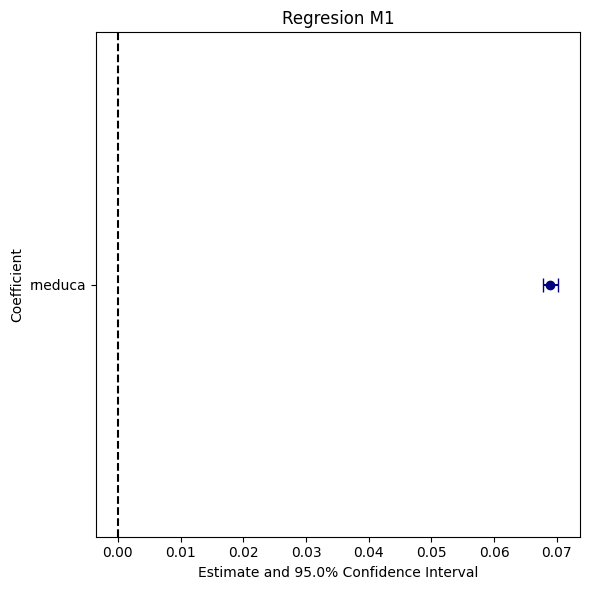

In [14]:
m1.coefplot(
    figsize=(6,6),
    title='Regresion M1',
    keep=['rneduca']
)

In [15]:

m1 = "logr6 ~ rneduca"
m2 = "logr6 ~ rneduca + rmujer + redad + redadsq + rinformal"
m3 = "logr6 ~ rneduca + rmujer + redad + redadsq + rinformal + C(ryear)"
m4 = "logr6 ~ rneduca + rmujer + redad + redadsq + rinformal + C(ryear) + C(rDpto)"

model_equations = [m1, m2, m3, m4]

regs = []
for equation in model_equations:
    regs.append(pf.feols(equation, base))

In [16]:
pf.etable(regs[:4], 
          keep=['rneduca','Intercept']
         )

GT(_tbl_data=  level_0             level_1                      0                      1  \
0    coef             rneduca  0.069*** <br> (0.001)  0.038*** <br> (0.001)   
1    coef           Intercept  6.117*** <br> (0.007)  5.923*** <br> (0.030)   
2   stats        Observations                  95224                  95224   
3   stats           S.E. type                 hetero                 hetero   
4   stats       R<sup>2</sup>                  0.115                  0.328   
5   stats  Adj. R<sup>2</sup>                  0.115                  0.328   

                       2                      3  
0  0.038*** <br> (0.001)  0.035*** <br> (0.001)  
1  5.865*** <br> (0.030)  5.898*** <br> (0.033)  
2                  95224                  95224  
3                 hetero                 hetero  
4                  0.331                  0.346  
5                  0.331                  0.346  , _body=<great_tables._gt_data.Body object at 0x0000019AB44F3190>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019AB44F54D0>, _spanners=Spanners([SpannerInfo(spanner_id='logr6', spanner_level=1, spanner_label='logr6', spanner_units=None, spanner_pattern=None, vars=['0', '1', '2', '3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019AB44F4F10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019AB454EB10>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019AB445ED90>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, categor

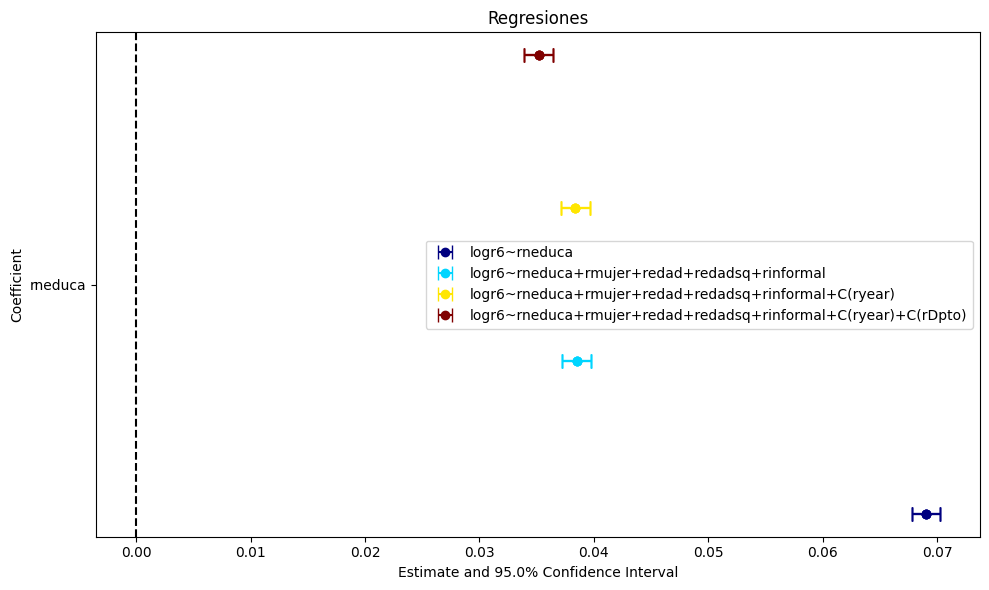

In [17]:
pf.coefplot(    
    regs[:4],
    title='Regresiones',
    keep=['rneduca']
)

In [18]:
#import pandas as pd
#pip install openpyxl

# Obtener la tabla como DataFrame
df_tabla1 = pf.etable(
    regs[:4],
    keep=['rneduca', 'Intercept'],
    type="df"  # clave para obtener un DataFrame
)

# Ahora df_tabla1 es un DataFrame real
print(type(df_tabla1))  # debería decir <class 'pandas.core.frame.DataFrame'>

# Exportar a Excel
df_tabla1.to_excel(data_in+"T1.xlsx", index=False)

<class 'pandas.core.frame.DataFrame'>


# Pregunta 2

In [20]:
import statsmodels.formula.api as smf
m4 = "logr6 ~ rneduca + rmujer + redad + redadsq + rinformal + C(ryear) + C(rDpto)"
modelo4 = smf.ols(m4, data=base).fit()
residuals = modelo4.resid
base["rerror"] = residuals
base["rerrorsq"] = base["rerror"]* base["rerror"]

<Axes: xlabel='rerror', ylabel='Density'>

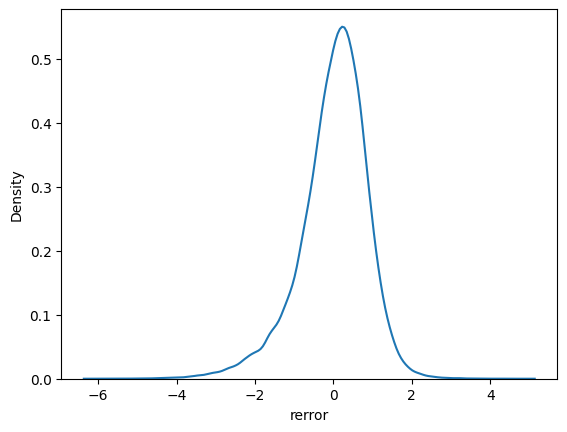

In [22]:
sns.kdeplot(
    data=base,
    x='rerror'
)

<Axes: ylabel='rerror'>

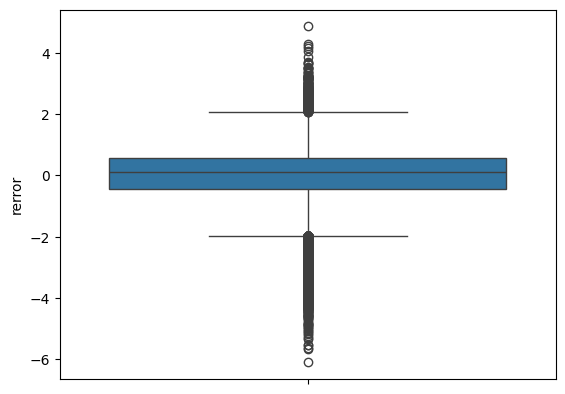

In [24]:
sns.boxplot(
    data=base,
    y='rerror'
)

In [32]:
formula = "rerrorsq ~ rneduca +C(reduca)+ rmujer + redad + redadsq + rinformal"
hetero = pf.feols(formula, base)

In [33]:
pf.etable(hetero, 
          keep=['rneduca','reduca','rmujer','redad','redadsq','rinformal']
         )

GT(_tbl_data=   level_0             level_1                       0
0     coef             rneduca  -0.012*** <br> (0.003)
1     coef      C(reduca)[T.3]    0.105** <br> (0.034)
2     coef      C(reduca)[T.4]     0.116* <br> (0.046)
3     coef      C(reduca)[T.5]   0.262*** <br> (0.052)
4     coef      C(reduca)[T.6]   1.976*** <br> (0.335)
5     coef              rmujer   0.342*** <br> (0.010)
6     coef               redad  -0.030*** <br> (0.002)
7     coef             redadsq   0.000*** <br> (0.000)
8     coef           rinformal   0.393*** <br> (0.013)
9    stats        Observations                   95224
10   stats           S.E. type                     iid
11   stats       R<sup>2</sup>                   0.028
12   stats  Adj. R<sup>2</sup>                   0.028, _body=<great_tables._gt_data.Body object at 0x0000019ABCA3BDD0>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019ABCA5C7D0>, _spanners=Spanners([SpannerInfo(spanner_id='rerrorsq', spanner_level=1, spanner_label='rerrorsq', spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019ABCA3A510>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019ABCA3AD90>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019ABCA38A90>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='valu

In [44]:
from scipy.stats import chi2
valor_critico = chi2.ppf(1 - 0.05, df=9)
print('valor Chi-cuadrado :', valor_critico)


valor Chi-cuadrado : 16.918977604620448


#  Pregunta 3

In [36]:
model = "logr6 ~ rneduca + rmujer + redad + redadsq + rinformal + C(reduca)"
m4a = pf.feols(model, base, vcov='HC1')
m4b = pf.feols(model, base)


In [38]:
pf.etable([m4a,m4b] ,
          keep=['rneduca','redad','redadsq','rinformal','reduca','rmujer']
         )

GT(_tbl_data=   level_0             level_1                       0                       1
0     coef             rneduca   0.053*** <br> (0.002)   0.053*** <br> (0.002)
1     coef               redad   0.073*** <br> (0.001)   0.073*** <br> (0.001)
2     coef             redadsq  -0.001*** <br> (0.000)  -0.001*** <br> (0.000)
3     coef           rinformal  -0.917*** <br> (0.007)  -0.917*** <br> (0.008)
4     coef      C(reduca)[T.3]  -0.236*** <br> (0.021)  -0.236*** <br> (0.020)
5     coef      C(reduca)[T.4]  -0.270*** <br> (0.028)  -0.270*** <br> (0.027)
6     coef      C(reduca)[T.5]  -0.121*** <br> (0.031)  -0.121*** <br> (0.030)
7     coef      C(reduca)[T.6]   -0.837** <br> (0.318)  -0.837*** <br> (0.197)
8     coef              rmujer  -0.487*** <br> (0.006)  -0.487*** <br> (0.006)
9    stats        Observations                   95224                   95224
10   stats           S.E. type                  hetero                     iid
11   stats       R<sup>2</sup>                   0.333                   0.333
12   stats  Adj. R<sup>2</sup>                   0.333                   0.333, _body=<great_tables._gt_data.Body object at 0x0000019AC2B6FB90>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019AC27E8ED0>, _spanners=Spanners([SpannerInfo(spanner_id='logr6', spanner_level=1, spanner_label='logr6', spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019AB6B17A90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019AC48D9410>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019AC48DA210>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'

# Pregunta 4

In [ ]:
#Presentacion en formato de tabla
# pf.etable(regs[:4])
# Regresion con interacciones
base['i1'] = base['rmujer'] * base['rneduca']
base['i2'] = base['rmujer'] * base['redad']
base['i3'] = base['rmujer'] * base['redadsq']
base['i4'] = base['rmujer'] * base['rinformal']

m5 = "logr6 ~ rneduca  + C(reduca) + rmujer + redad + redadsq + rinformal + i1 + i2 + i3 +i4"
regs.append(pf.feols(m5, base, vcov="HC1"))

In [ ]:
#print(pf.__version__)
pf.etable(regs[:5], 
          keep=['rneduca','rmujer','redad','redadsq','i1','Intercept']
         )

In [ ]:
m5a = "logr6 ~ rneduca  + C(reduca) + rmujer + redad + redadsq + rinformal + i1 + i2 + i3 +i4"
m5b = "logr6 ~ rneduca  + C(reduca)+  rmujer + redad + redadsq + rinformal"
m6  = "logr6 ~ rneduca  + C(reduca) + redad + redadsq + rinformal"


model1 = pf.feols(m5a, base, vcov="HC1")
model2 = pf.feols(m5b, base, vcov="HC1")
model3 = pf.feols(m6, base.loc[base['rmujer']==1], vcov="HC1")
model4 = pf.feols(m6, base.loc[base['rmujer']==0], vcov="HC1")


extendida = [model1 , model2, model3, model4]
pf.etable(extendida[:5], 
          keep=['rneduca','i1','Intercept']
         )